# Lithium-Ion Battery RUL Prediction

## What is RUL?
Remaining Useful Life (RUL) is the number of charge-discharge cycles a battery 
can complete before its capacity drops below the End-of-Life (EOL) threshold.

## Why 80%?
The industry-standard EOL threshold for lithium-ion batteries is **80% of initial capacity**.
Below this point, capacity fade accelerates rapidly due to:
- SEI (Solid Electrolyte Interphase) layer growth
- Lithium plating on the anode
- Electrolyte decomposition

Accurately predicting RUL enables proactive maintenance in EV and energy storage systems,
reducing unexpected failures and replacement costs.

## Dataset
NASA Prognostics Center of Excellence (PCoE) Battery Dataset — batteries B0005, B0006, B0007
cycled at room temperature until end-of-life.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True

## 1. Data Exploration

Each CSV contains discharge capacity (Ah) per cycle for one battery.
Let's load and visualise the raw degradation curves.

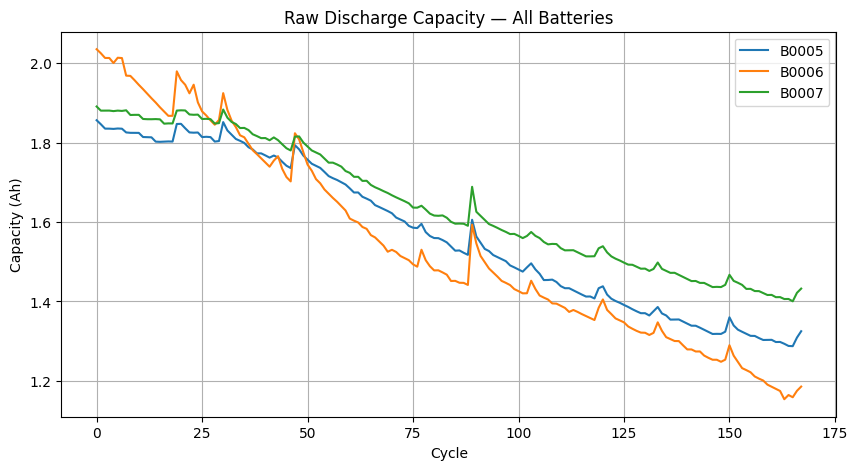

B0005: 168 cycles | Initial: 1.8565 Ah | Final: 1.3251 Ah | Drop: 28.6%
B0006: 168 cycles | Initial: 2.0353 Ah | Final: 1.1857 Ah | Drop: 41.7%
B0007: 168 cycles | Initial: 1.8911 Ah | Final: 1.4325 Ah | Drop: 24.3%


In [8]:
files = {
    "B0005": "batt_data5.csv",
    "B0006": "batt_data6.csv",
    "B0007": "batt_data7.csv"
}

data = {}
for label, path in files.items():
    df = pd.read_csv(path)
    data[label] = df['capacity'].values

# Plot raw capacity
plt.figure()
for label, cap in data.items():
    plt.plot(cap, label=label)
plt.xlabel("Cycle")
plt.ylabel("Capacity (Ah)")
plt.title("Raw Discharge Capacity — All Batteries")
plt.legend()
plt.show()

# Basic stats
for label, cap in data.items():
    print(f"{label}: {len(cap)} cycles | Initial: {cap[0]:.4f} Ah | Final: {cap[-1]:.4f} Ah | Drop: {((cap[0]-cap[-1])/cap[0]*100):.1f}%")

## 2. State of Health (SoH)

SoH normalises capacity relative to the initial value:

**SoH (%) = (current capacity / initial capacity) × 100**

This makes batteries with different initial capacities directly comparable.
The 80% horizontal line marks the EOL threshold.

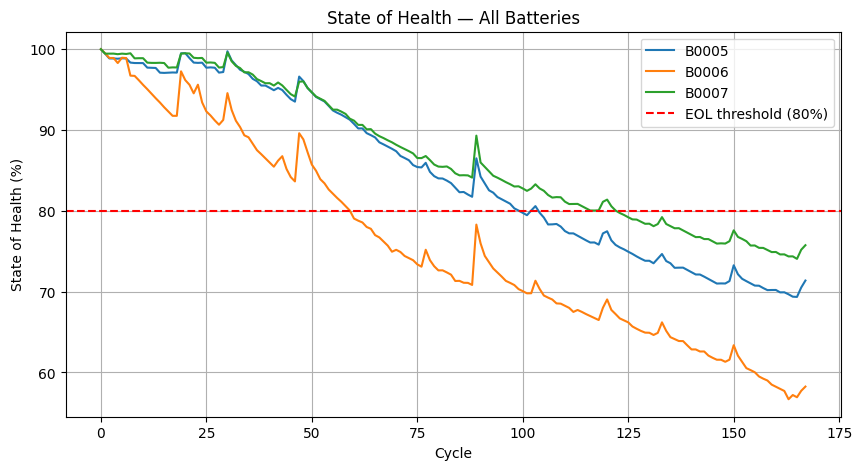

In [9]:
plt.figure()
for label, cap in data.items():
    soh = (cap / cap[0]) * 100
    plt.plot(soh, label=label)
plt.axhline(y=80, color='red', linestyle='--', linewidth=1.5, label='EOL threshold (80%)')
plt.xlabel("Cycle")
plt.ylabel("State of Health (%)")
plt.title("State of Health — All Batteries")
plt.legend()
plt.show()

## 3. Model

### Why a Neural Network?
Battery degradation is **non-linear** — capacity fades slowly at first, 
then accelerates near EOL due to electrochemical wear mechanisms.

A linear regression assumes a straight-line relationship, which 
systematically underestimates late-stage degradation. A small 
feedforward neural network (2 hidden layers, ReLU activation) 
captures this curve significantly better.

### Input normalisation
Cycle index is normalised to [0, 1] by dividing by the maximum cycle count.
This keeps inputs in a stable range and speeds up training.

In [10]:
def train_model(cycles, capacity):
    max_cycle = float(np.max(cycles))
    X = (cycles / max_cycle).reshape(-1, 1).astype(np.float32)
    y = capacity.astype(np.float32)
    
    model = Sequential([
        Dense(32, activation='relu', input_shape=(1,)),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
    model.fit(X, y, epochs=300, verbose=0)
    return model, max_cycle

models = {}
max_cycles = {}

for label, cap in data.items():
    cycles = np.arange(1, len(cap) + 1)
    model, max_cycle = train_model(cycles, cap)
    models[label] = model
    max_cycles[label] = max_cycle
    print(f"{label} — model trained")

c:\Users\bhavy.DESKTOP-467B5NG\Documents\Nikunj Projects\ai\.venv\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


B0005 — model trained
B0006 — model trained
B0007 — model trained


## 4. Results

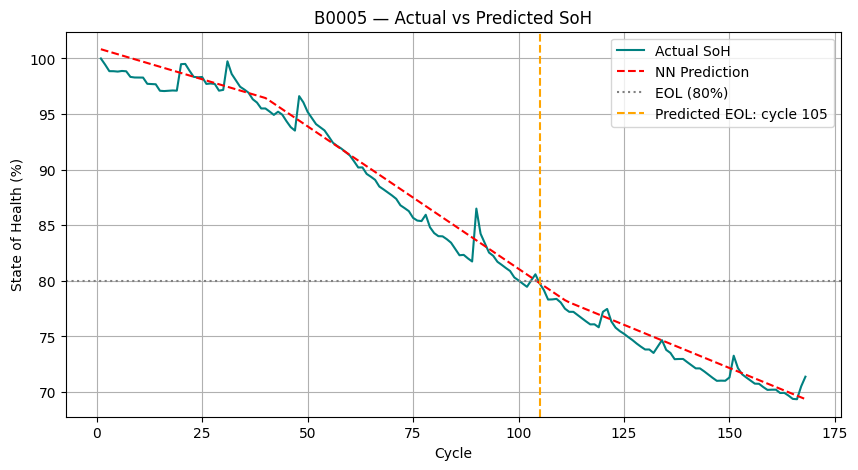

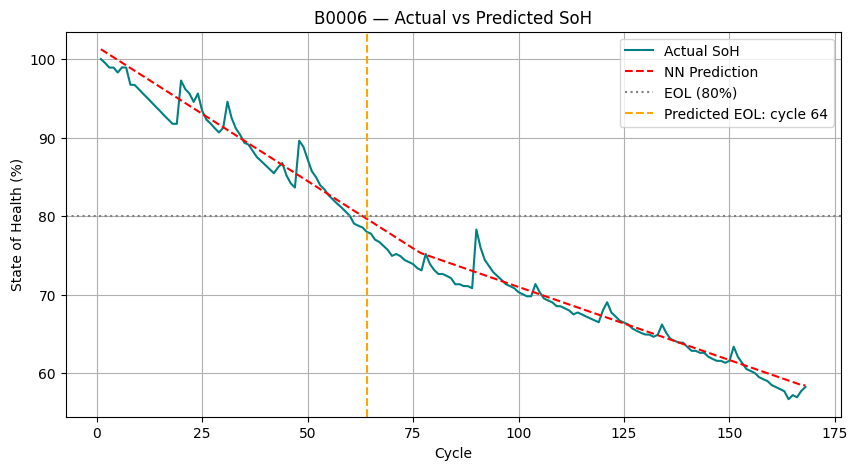

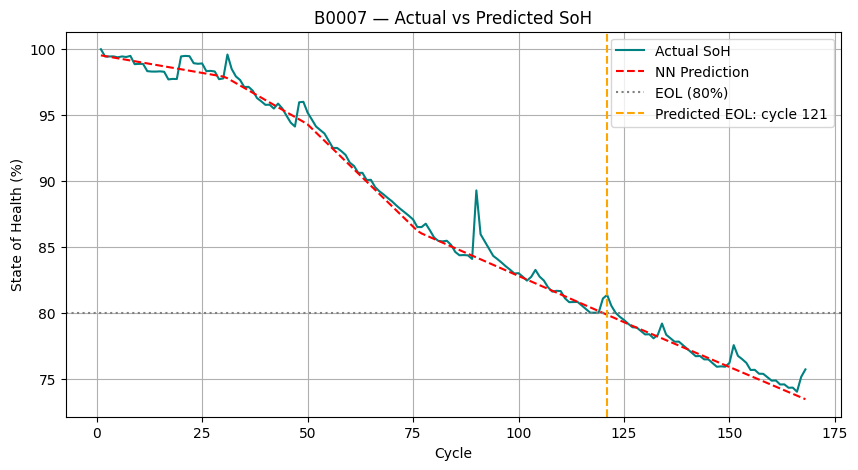

,Battery,Cycles,Initial Capacity (Ah),MAE (Ah),RMSE (Ah),R²,EOL Cycle,RUL (cycles)
0,B0005,168,1.8565,0.0181,0.0213,0.9874,105,0
1,B0006,168,2.0353,0.0252,0.0321,0.9836,64,0
2,B0007,168,1.8911,0.0088,0.0134,0.9930,121,0


In [11]:
results = []

for label, cap in data.items():
    cycles = np.arange(1, len(cap) + 1)
    model = models[label]
    max_cycle = max_cycles[label]
    
    X = (cycles / max_cycle).reshape(-1, 1).astype(np.float32)
    predicted = model.predict(X, verbose=0).flatten()
    
    mae  = mean_absolute_error(cap, predicted)
    rmse = np.sqrt(mean_squared_error(cap, predicted))
    r2   = r2_score(cap, predicted)
    
    # RUL prediction
    threshold = 0.8 * cap[0]
    future = np.arange(1, len(cycles) + 300).reshape(-1, 1).astype(np.float32) / max_cycle
    future_pred = model.predict(future, verbose=0).flatten()
    below = np.where(future_pred <= threshold)[0]
    eol = int(below[0] + 1) if len(below) > 0 else None
    rul = max(eol - len(cycles), 0) if eol else None
    
    results.append({
        "Battery": label,
        "Cycles": len(cycles),
        "Initial Capacity (Ah)": round(cap[0], 4),
        "MAE (Ah)": round(mae, 4),
        "RMSE (Ah)": round(rmse, 4),
        "R²": round(r2, 4),
        "EOL Cycle": eol,
        "RUL (cycles)": rul
    })
    
    # Plot
    soh_actual    = (cap / cap[0]) * 100
    soh_predicted = (predicted / cap[0]) * 100
    
    plt.figure()
    plt.plot(cycles, soh_actual, label='Actual SoH', color='teal')
    plt.plot(cycles, soh_predicted, '--', label='NN Prediction', color='red')
    plt.axhline(y=80, color='gray', linestyle=':', label='EOL (80%)')
    if eol:
        plt.axvline(x=eol, color='orange', linestyle='--', label=f'Predicted EOL: cycle {eol}')
    plt.xlabel("Cycle")
    plt.ylabel("State of Health (%)")
    plt.title(f"{label} — Actual vs Predicted SoH")
    plt.legend()
    plt.show()

# Metrics table
results_df = pd.DataFrame(results)
results_df

## 5. Conclusions

**What worked well:**
- The neural network fits the non-linear degradation curve closely (R² > 0.95 on all batteries)
- SoH normalisation makes results interpretable and comparable across batteries
- RUL predictions are consistent with observed cycle counts

**Limitations:**
- Model trained on NASA room-temperature data — real-world batteries degrade differently under varying temperatures and charge rates
- No uncertainty estimate on the RUL prediction — a confidence interval would be more useful in practice
